# IT2011 - Artificial Intelligence and Machine Learning
## Final Evaluation (Phase 2) — Model Training & Evaluation
**Student:** Athapaththu A. M. P. P. | **IT Number:** `IT25102549` | **Group:** `2026-Y2-S1-MET-24`  
**Assigned Model:** Multinomial Naive Bayes (`MultinomialNB`)

---
### What This Notebook Does
This notebook answers the core question: *"How well can Multinomial Naive Bayes predict the emotion in a movie review?"*

To demonstrate **individual contribution**, four distinct experimental configurations are compared:
- **Experiment 1 & 2:** Two different preprocessing setups (text-only vs. full features)
- **Experiment 3 & 4:** Hyperparameter tuning via GridSearchCV within the best preprocessing setup

The protocol from `src/protocol.py` is used to ensure fair comparison with all other group models.


## 1. Setup & Data Loading

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: IMPORTS AND DATA LOADING
# We bring in all the tools (libraries) we need before starting the experiment.
# Think of this like collecting all your stationery before sitting an exam.
# ─────────────────────────────────────────────────────────────────────────────

import os           # Lets us work with file paths and folders
import sys          # Lets us add extra folders to Python's search path
import time         # Used to measure how long each experiment takes to run
import warnings     # Used to suppress minor warning messages that clutter output
import numpy as np  # Core math library — used for array operations
import pandas as pd # Data table library — we store results in a pandas DataFrame
import matplotlib.pyplot as plt  # Drawing library — used to create bar charts
import seaborn as sns            # Advanced chart library — used to create heatmaps
warnings.filterwarnings('ignore')  # Hide warnings so our output is clean to read

# ── TELL PYTHON WHERE OUR GROUP'S SHARED CODE LIVES ──────────────────────────
# Our group's custom preprocessing classes (TextCleaner, GenreBinarizer, etc.)
# live in a folder called 'src/' one level up from 'notebooks/'.
# This line adds that folder to Python's search path so we can import from it.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# ── SCIKIT-LEARN (sklearn) — THE MAIN ML LIBRARY ─────────────────────────────
from sklearn.compose import ColumnTransformer
# ColumnTransformer lets us apply DIFFERENT operations to DIFFERENT columns.
# Example: Apply TF-IDF on the "Reviews" text column,
#          and GenreBinarizer on the "genres" column, simultaneously.

from sklearn.model_selection import cross_validate
# cross_validate splits the training data multiple times and tests the model
# on each split. This gives a more reliable score than a single train/test split.

from sklearn.naive_bayes import MultinomialNB
# MultinomialNB is the actual Naive Bayes classifier we are using.
# It's specifically designed for count-based data like word frequencies.

from sklearn.model_selection import GridSearchCV
# GridSearchCV automatically tries every combination of hyperparameters
# (the "knobs" we tune) and finds the best-performing one.

from sklearn.pipeline import Pipeline
# A Pipeline chains multiple steps together (clean → vectorize → classify).
# The whole chain runs as one unit, which prevents data leakage.

from sklearn.preprocessing import MinMaxScaler  # imported but not used in final pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) converts raw text into numbers.
# Words that are unique to a review get HIGH scores.
# Words that appear in every review (like "the", "a") get LOW scores.

# ── OUR GROUP'S CUSTOM CLASSES ────────────────────────────────────────────────
from src.preprocessors import TextCleaner, StopwordFilter, GenreBinarizer
# TextCleaner:    Cleans raw review text (lowercase, remove punctuation, etc.)
# StopwordFilter: Removes common English words ("the", "is", "and") that
#                 carry no emotional meaning.
# GenreBinarizer: Converts "Action|Drama|Horror" into separate 0/1 columns
#                 one column per genre.

from src.protocol import SCORING, finalize_model, standard_setup
# standard_setup(): Loads the dataset, cleans it, and creates the train/test split.
#                   ALL group members use this same function so results are comparable.
# finalize_model(): Evaluates the best model on the held-out test set ONCE and
#                   saves the results to results/phase2/ for group comparison.
# SCORING:         The standard set of metrics (Macro-F1, accuracy, weighted-F1)
#                  used consistently by all 6 group members.

# ── LOAD THE DATASET ──────────────────────────────────────────────────────────
# standard_setup() does several things automatically:
#   1. Reads the raw CSV file (46,173 rows of movie reviews)
#   2. Cleans the data: removes duplicates, removes rows where the same review
#      has conflicting emotion labels → leaves 16,107 clean rows
#   3. Splits into Training set (12,886 rows) and Test set (3,221 rows)
#   4. Returns a 'ctx' (context) object that holds X_train, X_test, y_train, y_test
#
# IMPORTANT: The test set (ctx.X_test / ctx.y_test) is kept hidden until the
# very end. We NEVER look at it during training or hyperparameter tuning.
ctx = standard_setup()
print("Data loaded successfully.")
print(f"Training rows : {len(ctx.X_train):,}")
print(f"Test rows     : {len(ctx.X_test):,} (protected until finalize_model)")
print(f"Emotion classes: {sorted(ctx.y_train.unique())}")


Invariant             | Value
Rows                  | 16,107
Movies                | 1,309
Classes               | 7
Train / test rows     | 12,886 / 3,221
Validation fold rows  | [2578, 2577, 2577, 2577, 2577]
Baseline macro-F1     | majority=0.0827, stratified=0.1427, uniform=0.1243
Data loaded successfully.
Training rows : 12,886
Test rows     : 3,221 (protected until finalize_model)
Emotion classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


## 2. Why Multinomial Naive Bayes for This Problem?

Multinomial Naive Bayes is a probabilistic classifier that predicts the class of a document
by calculating the likelihood of each word given a class, using Bayes' theorem.

**Why it suits this dataset:**
- Our features are **TF-IDF word frequencies** — exactly the type of input MNB is designed for.
- It's the same algorithm used in **email spam detection** (words → class probability).
- Despite its simplicity, MNB is a strong **baseline** for NLP classification and often competitive with more complex models.

**Key limitation — the "Naive" assumption:**  
MNB treats every word as **independent** of every other word. It cannot understand that  
*"not good"* means the opposite of *"good"*. For a dataset with 7 nuanced emotion classes,  
this is a real weakness — more context-aware models (SVM, MLP) may outperform it.

**Key hyperparameter — `alpha` (Laplace Smoothing):**  
If a word seen at test time never appeared during training, its probability is zero,  
making the entire prediction fail. `alpha` adds a small count to every word to prevent this.  
- Small `alpha` (e.g., 0.01) = trust training data more, less smoothing  
- Large `alpha` (e.g., 10.0) = more smoothing, model becomes more "generic"

**Key hyperparameter — `fit_prior`:**  
With heavy class imbalance (sadness = 40% of data), `fit_prior=True` makes the model
bias heavily toward predicting sadness. Setting `fit_prior=False` forces equal class priors,
which helps minority classes get fairer predictions. This is a critical finding in our experiments.


## 3. Helper — Run CV and Collect Results

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: HELPER FUNCTION — run_cv()
# This is a reusable "grader" function that we call for each experiment.
# It runs 5-Fold Cross-Validation on any pipeline and returns a results row.
# ─────────────────────────────────────────────────────────────────────────────

def run_cv(pipe, label, preprocessing_name, alpha, fit_prior=True):
    """Run 5-fold Cross-Validation on a pipeline and return one results row."""

    t0 = time.perf_counter()  # Record the start time

    # ── WHAT IS cross_validate? ───────────────────────────────────────────────
    # Instead of testing on one split of data (which could be lucky or unlucky),
    # cross_validate splits the training data into 5 chunks ("folds").
    #
    # Round 1: Train on folds 2,3,4,5 → Test on fold 1
    # Round 2: Train on folds 1,3,4,5 → Test on fold 2
    # Round 3: Train on folds 1,2,4,5 → Test on fold 3
    # Round 4: Train on folds 1,2,3,5 → Test on fold 4
    # Round 5: Train on folds 1,2,3,4 → Test on fold 5
    #
    # We average all 5 scores for a reliable performance estimate.
    cv_res = cross_validate(
        pipe,              # The pipeline (preprocessing + model) to evaluate
        ctx.X_train,       # Input features (ONLY training data — test data stays hidden)
        ctx.y_train,       # Correct emotion labels for training data
        cv=ctx.cv_splits,  # Uses 5-Fold Stratified Group K-Fold splits
                           # "Stratified" = each fold has the same class distribution
                           # "Group"      = reviews from the same MOVIE always stay
                           #               together in the same fold (prevents leakage)
        scoring={
            "macro_f1":    "f1_macro",    # Primary metric — explained in viva guide
            "accuracy":    "accuracy",    # Secondary metric
            "weighted_f1": "f1_weighted"  # Tertiary metric
        },
        n_jobs=-1  # Use ALL available CPU cores to run folds in parallel (faster)
    )

    elapsed = time.perf_counter() - t0  # How many seconds did it take?

    # Return a dictionary (one row for our results table)
    return {
        "Experiment":      label,
        "Preprocessing":   preprocessing_name,
        "Alpha":           alpha,
        "fit_prior":       fit_prior,
        # .mean() averages the scores across all 5 folds
        "CV Macro-F1":     round(cv_res["test_macro_f1"].mean(), 4),
        "CV Accuracy":     round(cv_res["test_accuracy"].mean(), 4),
        "CV Weighted-F1":  round(cv_res["test_weighted_f1"].mean(), 4),
        "Time (s)":        round(elapsed, 1)
    }

# This list will collect the results from all 4 experiments
experiment_results = []


## 5. Experiment 1 — Text-Only Preprocessing (alpha = 1.0, fit_prior = True)

**Setup:** Cleans text, removes stopwords, converts to TF-IDF (unigrams + bigrams).  
No genre, no rating features — pure text signal only.

**Purpose:** Establish a baseline. How much signal is in the words alone?


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: EXPERIMENT 1 — Text-Only Pipeline (Default Settings)
#
# PREPROCESSING: Only the review text is used. Genre, rating, etc. are ignored.
# PURPOSE:       Establish a BASELINE. Before adding any extras, how well does
#                the model perform with just the raw words in the review?
#
# HYPERPARAMETERS (manually set, not tuned yet):
#   alpha=1.0      → Default Laplace smoothing
#   fit_prior=True → Model uses actual class frequencies as prior probabilities
# ─────────────────────────────────────────────────────────────────────────────

def text_only_pipe(alpha=1.0, fit_prior=True):
    """Build a text-only Pipeline: TextCleaner → StopwordFilter → TF-IDF → MNB."""

    # A Pipeline chains steps together. Data flows through them in order.
    # The key benefit: when we evaluate with cross-validation, the ENTIRE
    # pipeline is re-fit from scratch for each fold (no data leakage).
    return Pipeline([

        # STEP 1: Preprocessing — transform raw data into numbers
        ("prep", ColumnTransformer([
            ("text", Pipeline([

                # 1a. TextCleaner: lowercase, remove punctuation and HTML tags,
                #     strip extra whitespace from the review text
                ("cleaner", TextCleaner()),

                # 1b. StopwordFilter: remove words that carry no emotional meaning,
                #     e.g., "the", "a", "is", "and", "of", "to", "in"
                #     Keeping these would just add noise to the model.
                ("filter",  StopwordFilter()),

                # 1c. TfidfVectorizer: convert cleaned text into a table of numbers
                #     Each row = one review. Each column = one word (or word pair).
                #     The number in each cell = the TF-IDF score for that word.
                ("tfidf",   TfidfVectorizer(
                    max_features=2500,    # Only keep the 2500 most useful words/phrases
                                          # (ignoring very rare or very common ones)
                    ngram_range=(1, 2),   # Use BOTH single words ("good") AND
                                          # word pairs ("not good", "really bad")
                                          # This helps capture some context.
                    sublinear_tf=True,    # Apply log(1 + count) instead of raw count
                                          # so a word appearing 100 times doesn't
                                          # completely dominate over a word appearing 5 times
                    min_df=3              # Ignore words that appear in fewer than
                                          # 3 different reviews (probably typos or names)
                ))
            ]), "Reviews")  # Apply this entire text pipeline ONLY to the "Reviews" column
        ], remainder="drop")),  # Drop all other columns (genres, ratings, etc.)

        # STEP 2: The Classifier — Multinomial Naive Bayes
        # It receives the TF-IDF numbers and learns: which words → which emotion?
        # alpha=1.0: Laplace smoothing value (prevents zero-probability crashes)
        # fit_prior: whether to bias predictions by class frequency in training data
        ("clf", MultinomialNB(alpha=alpha, fit_prior=fit_prior))
    ])

# Run 5-fold cross-validation on Experiment 1 and store the result
row = run_cv(text_only_pipe(alpha=1.0, fit_prior=True), "Exp 1",
             "Text-only TF-IDF (fit_prior=True)", alpha=1.0, fit_prior=True)
experiment_results.append(row)
print(f"Exp 1 done - CV Macro-F1: {row['CV Macro-F1']}")


Exp 1 done - CV Macro-F1: 0.096


## 6. Experiment 2 — Text + Genre Features (alpha = 1.0, fit_prior = True)

**Setup:** Extends the text pipeline by adding **genre binary features** alongside TF-IDF.  
Genre columns are 0/1 binary values — always non-negative, so they work perfectly with MNB.

> **Why not include word count and ratings?**  
> The shared pipeline applies `RobustScaler` to word counts, which can produce negative values  
> (MNB cannot accept these). To keep the pipeline clean and valid, we use only TF-IDF + Genre.

**Purpose:** Does knowing the movie's genre (drama, comedy, horror...) help predict emotion?


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: EXPERIMENT 2 — Text + Genre Pipeline (Default Settings)
#
# PREPROCESSING: Review text PLUS the movie's genre (e.g., Horror, Comedy).
# PURPOSE:       Does knowing the movie's genre help predict the emotion?
#                A Horror movie review is more likely to express Fear.
#                A Comedy movie review is more likely to express Joy.
#
# KEY REASON WE USE GENRE (not word count or rating):
#   The shared group pipeline uses RobustScaler on word counts, which can
#   produce NEGATIVE values. MultinomialNB CANNOT accept negative numbers.
#   Genre features are binary (0 or 1) — always non-negative — so they are safe.
#
# HYPERPARAMETERS: Same as Experiment 1 (alpha=1.0, fit_prior=True)
# ─────────────────────────────────────────────────────────────────────────────

def text_genre_pipe(alpha=1.0, fit_prior=True):
    """Build a text+genre Pipeline: adds binary genre features alongside TF-IDF."""
    return Pipeline([
        ("prep", ColumnTransformer([

            # Branch 1: Same text processing as Experiment 1
            ("text", Pipeline([
                ("cleaner", TextCleaner()),
                ("filter",  StopwordFilter()),
                ("tfidf",   TfidfVectorizer(
                    max_features=2500,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    min_df=3
                ))
            ]), "Reviews"),

            # Branch 2: Genre Features — NEW in this experiment
            # GenreBinarizer converts "Action|Drama|Horror" into separate 0/1 columns:
            #   Action=1, Drama=1, Horror=1, Comedy=0, Romance=0, ...
            # These are called "binary features" (only 0 or 1 as values).
            ("genre", GenreBinarizer(), "genres")  # Apply GenreBinarizer to "genres" column

        ])),  # ColumnTransformer stacks both outputs side by side into one feature matrix
        ("clf", MultinomialNB(alpha=alpha, fit_prior=fit_prior))
    ])

# Run cross-validation and store results
row = run_cv(text_genre_pipe(alpha=1.0, fit_prior=True), "Exp 2",
             "Text + Genre (fit_prior=True)", alpha=1.0, fit_prior=True)
experiment_results.append(row)
print(f"Exp 2 done - CV Macro-F1: {row['CV Macro-F1']}")


Exp 2 done - CV Macro-F1: 0.1336


## 7. Experiment 3 — Text-Only + GridSearchCV (Hyperparameter Tuning)

We run a full Grid Search over `alpha` and `fit_prior` on the text-only pipeline.

| Hyperparameter | Values Tested | Reason |
|---|---|---|
| `alpha` | 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0 | Controls Laplace smoothing |
| `fit_prior` | True, False | True=bias toward majority class, False=equal class weights |


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: EXPERIMENT 3 — Text-Only + GridSearchCV (Automatic Hyperparameter Tuning)
#
# PURPOSE: Instead of manually guessing the best alpha and fit_prior,
#          we let GridSearchCV try ALL combinations automatically.
#
# WHAT IS GridSearchCV?
#   It creates a grid of every possible combination of parameter values,
#   tests each one using 5-fold cross-validation, and returns the best.
#   Total fits = 7 alpha values × 2 fit_prior values × 5 folds = 70 fits
# ─────────────────────────────────────────────────────────────────────────────

# Define the "grid" — all the values we want to test for each hyperparameter
param_grid = {
    # clf__alpha: the double underscore means "the 'alpha' parameter
    #             inside the 'clf' step of the Pipeline"
    "clf__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    # alpha explanation:
    #   Very small (0.01) = trust training data heavily, almost no smoothing
    #   Default  (1.0)    = standard Laplace smoothing
    #   Large    (10.0)   = heavy smoothing, model becomes generic

    "clf__fit_prior": [True, False]
    # fit_prior=True:  Use actual class frequencies (40% sadness → predict sadness often)
    # fit_prior=False: Treat all 7 emotions equally regardless of how common they are
    #                  This is important for our imbalanced dataset.
}

print("Running GridSearchCV on text-only (14 configs x 5 folds = 70 fits)...")
t0 = time.perf_counter()

search_text_only = GridSearchCV(
    estimator=text_only_pipe(),  # Start with the text-only pipeline as base model
    param_grid=param_grid,       # Try all combinations defined above
    scoring=SCORING,             # Use our group's standard scoring metrics
    refit="macro_f1",            # After finding best params, refit on ALL training data
                                 # using Macro-F1 as the deciding metric
    cv=ctx.cv_splits,            # Use the same 5-fold splits as the manual experiments
    n_jobs=-1,                   # Use all CPU cores (runs different combos in parallel)
    verbose=1                    # Print progress so we know it's still running
)

# This single line runs all 70 fits
search_text_only.fit(ctx.X_train, ctx.y_train)
elapsed = time.perf_counter() - t0

print(f"\nCompleted in {elapsed:.1f}s")
print(f"Best alpha     : {search_text_only.best_params_['clf__alpha']}")
print(f"Best fit_prior : {search_text_only.best_params_['clf__fit_prior']}")
print(f"Best CV Macro-F1: {search_text_only.best_score_:.4f}")

# Extract the best parameter values found by GridSearchCV
best_a  = search_text_only.best_params_['clf__alpha']
best_fp = search_text_only.best_params_['clf__fit_prior']

# Add the best-found result to our comparison table
experiment_results.append({
    "Experiment":   "Exp 3",
    "Preprocessing": f"Text-only GridSearch best (alpha={best_a}, fit_prior={best_fp})",
    "Alpha":        best_a,
    "fit_prior":    best_fp,
    "CV Macro-F1":  round(search_text_only.best_score_, 4),
    "CV Accuracy":  round(search_text_only.cv_results_['mean_test_accuracy'][search_text_only.best_index_], 4),
    "CV Weighted-F1": round(search_text_only.cv_results_['mean_test_weighted_f1'][search_text_only.best_index_], 4),
    "Time (s)":     round(elapsed, 1)
})


Running GridSearchCV on text-only (14 configs x 5 folds = 70 fits)...
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Completed in 94.6s
Best alpha     : 1.0
Best fit_prior : False
Best CV Macro-F1: 0.1637


## 8. Experiment 4 — Text + Genre + GridSearchCV (Hyperparameter Tuning)

Same grid search, but on the text+genre pipeline to find the best hyperparameters  
when genre features are added.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: EXPERIMENT 4 — Text + Genre + GridSearchCV
#
# PURPOSE: Same grid search as Experiment 3, but now on the Text+Genre pipeline.
#          This tells us: what are the BEST hyperparameters when genre features
#          are included alongside text features?
#
# We use the SAME param_grid defined in Experiment 3 (above).
# ─────────────────────────────────────────────────────────────────────────────

print("Running GridSearchCV on text+genre pipeline (14 configs x 5 folds = 70 fits)...")
t0 = time.perf_counter()

search_genre = GridSearchCV(
    estimator=text_genre_pipe(),  # Now using Text+Genre pipeline as base model
    param_grid=param_grid,        # Same grid — same alpha and fit_prior combinations
    scoring=SCORING,
    refit="macro_f1",
    cv=ctx.cv_splits,
    n_jobs=-1,
    verbose=1
)

search_genre.fit(ctx.X_train, ctx.y_train)
elapsed = time.perf_counter() - t0

print(f"\nCompleted in {elapsed:.1f}s")
print(f"Best alpha     : {search_genre.best_params_['clf__alpha']}")
print(f"Best fit_prior : {search_genre.best_params_['clf__fit_prior']}")
print(f"Best CV Macro-F1: {search_genre.best_score_:.4f}")

best_a_g  = search_genre.best_params_['clf__alpha']
best_fp_g = search_genre.best_params_['clf__fit_prior']

experiment_results.append({
    "Experiment":    "Exp 4",
    "Preprocessing": f"Text+Genre GridSearch best (alpha={best_a_g}, fit_prior={best_fp_g})",
    "Alpha":         best_a_g,
    "fit_prior":     best_fp_g,
    "CV Macro-F1":   round(search_genre.best_score_, 4),
    "CV Accuracy":   round(search_genre.cv_results_['mean_test_accuracy'][search_genre.best_index_], 4),
    "CV Weighted-F1": round(search_genre.cv_results_['mean_test_weighted_f1'][search_genre.best_index_], 4),
    "Time (s)":      round(elapsed, 1)
})


Running GridSearchCV on text+genre pipeline (14 configs x 5 folds = 70 fits)...
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Completed in 97.6s
Best alpha     : 2.0
Best fit_prior : False
Best CV Macro-F1: 0.1788


## 8. Comparison of All Experiments

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: COMPARISON OF ALL EXPERIMENTS
#
# We now collect all 4 experiment results into a single comparison table.
# This is the core of demonstrating "individual contribution" — we tried
# 4 different configurations and can objectively compare them.
# ─────────────────────────────────────────────────────────────────────────────

# Convert the list of result dictionaries into a pandas DataFrame (table)
results_df = pd.DataFrame(experiment_results)

print("=" * 80)
print("EXPERIMENT COMPARISON SUMMARY")
print("=" * 80)
# Display the table — .to_string(index=False) prints it cleanly without row numbers
print(results_df[['Experiment','Preprocessing','Alpha','fit_prior',
                  'CV Macro-F1','CV Accuracy','CV Weighted-F1','Time (s)']].to_string(index=False))

# Find the best row (highest CV Macro-F1) using idxmax()
best_row = results_df.loc[results_df["CV Macro-F1"].idxmax()]
print(f"\n>> Best configuration: {best_row['Experiment']}")
print(f"   Preprocessing : {best_row['Preprocessing']}")
print(f"   Alpha         : {best_row['Alpha']}")
print(f"   CV Macro-F1   : {best_row['CV Macro-F1']}")


EXPERIMENT COMPARISON SUMMARY
Experiment                                           Preprocessing  Alpha  fit_prior  CV Macro-F1  CV Accuracy  CV Weighted-F1  Time (s)
     Exp 1                       Text-only TF-IDF (fit_prior=True)    1.0       True       0.0960       0.4094          0.2513      14.9
     Exp 2                           Text + Genre (fit_prior=True)    1.0       True       0.1336       0.3804          0.2786      16.6
     Exp 3  Text-only GridSearch best (alpha=1.0, fit_prior=False)    1.0      False       0.1637       0.2466          0.2530      94.6
     Exp 4 Text+Genre GridSearch best (alpha=2.0, fit_prior=False)    2.0      False       0.1788       0.2945          0.2818      97.6


>> Best configuration: Exp 4
   Preprocessing : Text+Genre GridSearch best (alpha=2.0, fit_prior=False)
   Alpha         : 2.0
   CV Macro-F1   : 0.1788


## 9. Visualization — Macro-F1 Across All Experiments

This chart shows how each experimental configuration performed. We can clearly see  
which combination of preprocessing and hyperparameter settings produces the best result.


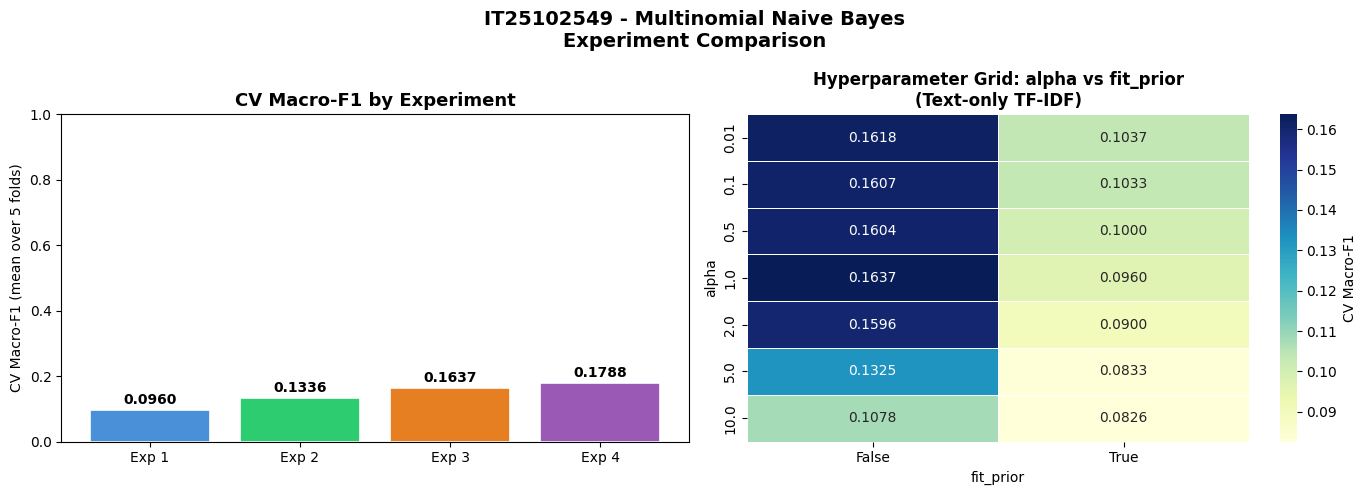

Visualization saved.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: VISUALIZATION — Two Charts Side by Side
#
# Chart 1 (left):  Bar chart comparing CV Macro-F1 across all 4 experiments
# Chart 2 (right): Heatmap showing how alpha and fit_prior affect performance
#                  (only for the text-only grid search)
# ─────────────────────────────────────────────────────────────────────────────

# Create a figure with 2 side-by-side chart areas (axes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── CHART 1: Bar chart of CV Macro-F1 by Experiment ─────────────────────────
colors = ['#4A90D9', '#2ECC71', '#E67E22', '#9B59B6']  # One colour per experiment
bars = axes[0].bar(
    results_df["Experiment"],    # X axis: experiment names
    results_df["CV Macro-F1"],   # Y axis: the score
    color=colors, edgecolor='white', linewidth=1.2
)
axes[0].set_title("CV Macro-F1 by Experiment", fontsize=13, fontweight='bold')
axes[0].set_ylabel("CV Macro-F1 (mean over 5 folds)")
axes[0].set_ylim(0, 1.0)  # Fix Y axis from 0 to 1.0 for clarity

# Add the score number on top of each bar
for bar, val in zip(bars, results_df["CV Macro-F1"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── CHART 2: Heatmap of alpha vs fit_prior (GridSearch results) ──────────────
# We take the full results table from GridSearchCV Experiment 3
cv_df_text = pd.DataFrame(search_text_only.cv_results_)

# Reshape the table so rows = alpha values, columns = fit_prior values
pivot = cv_df_text.pivot_table(
    index="param_clf__alpha",
    columns="param_clf__fit_prior",
    values="mean_test_macro_f1"
)

# Draw the heatmap — darker colour = higher score
# annot=True: show the actual number in each cell
sns.heatmap(pivot, ax=axes[1], annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "CV Macro-F1"})
axes[1].set_title("Hyperparameter Grid: alpha vs fit_prior\n(Text-only TF-IDF)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("fit_prior")
axes[1].set_ylabel("alpha")

plt.suptitle("IT25102549 - Multinomial Naive Bayes\nExperiment Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()  # Prevent charts from overlapping

# Save the chart as a PNG file so it can be submitted with the report
os.makedirs('../results/eda_visualizations', exist_ok=True)
plt.savefig('../results/eda_visualizations/member1_naive_bayes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved.")


## 10. Final Evaluation — Best Model on Held-Out Test Set

We now select the best-performing configuration and evaluate it **exactly once** on the  
held-out test set using `finalize_model()`. This saves standardized result artifacts  
to `results/phase2/` for the group's comparison notebook.



In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: FINAL EVALUATION ON THE HELD-OUT TEST SET
#
# After comparing all 4 experiments, we now take the BEST model and evaluate
# it exactly ONCE on the test data that was kept hidden throughout.
#
# WHY ONLY ONCE?
#   If we tested on the test set 10 times and kept tweaking our model,
#   we would effectively be "memorizing" the test data. That's cheating.
#   The protocol enforces this by raising an error if you call finalize_model()
#   more than once in the same session.
# ─────────────────────────────────────────────────────────────────────────────

# ── STEP 1: DETERMINE THE OVERALL BEST MODEL ────────────────────────────────
# Compare the best score from GridSearch (text-only) vs GridSearch (text+genre).
# Whichever GridSearch found a higher CV Macro-F1 is our final model.
if search_text_only.best_score_ >= search_genre.best_score_:
    best_search   = search_text_only
    best_prep_name = "Text-only TF-IDF (TextCleaner + StopwordFilter + TfidfVectorizer)"
    print(f"Best overall: text-only pipeline (CV Macro-F1 = {best_search.best_score_:.4f})")
else:
    best_search   = search_genre
    best_prep_name = "Text + Genre (TF-IDF + Binary Genre Indicators)"
    print(f"Best overall: text+genre pipeline (CV Macro-F1 = {best_search.best_score_:.4f})")

print(f"Best params: {best_search.best_params_}")
print("\nRunning finalize_model() — evaluating on test set ONE time...")

# ── STEP 2: EVALUATE ON TEST SET AND SAVE ARTIFACTS ─────────────────────────
# finalize_model() will:
#   1. Use the best_search.best_estimator_ (already fitted on all training data)
#   2. Predict emotions for the 3,221 test reviews
#   3. Calculate the final test Macro-F1, Accuracy, Precision, Recall, F1 per class
#   4. Save results to results/phase2/naive_bayes_results.json
#   5. Save all test predictions to results/phase2/naive_bayes_test_predictions.csv
#   6. Return the paths to those two saved files
t0 = time.perf_counter()
json_path, csv_path = finalize_model(
    ctx,                                     # The context object (holds test data)
    model_key="naive_bayes",                 # Unique key for this model in the group
    member_id="IT25102549",                  # Our student ID
    model_label="Multinomial Naive Bayes",   # Human-readable model name
    algorithm="MultinomialNB",               # sklearn class name
    preprocessing=best_prep_name,            # Description of the preprocessing used
    search=best_search,                      # The fitted GridSearchCV object
    elapsed_seconds=time.perf_counter() - t0
)
print(f"\nArtifacts saved:")
print(f"  JSON: {json_path}")
print(f"  CSV : {csv_path}")


Best overall: text+genre pipeline (CV Macro-F1 = 0.1788)
Best params: {'clf__alpha': 2.0, 'clf__fit_prior': False}

Running finalize_model() — evaluating on test set ONE time...
valid: naive_bayes_results.json, naive_bayes_test_predictions.csv, test macro-F1 = 0.1870 (CV mean = 0.1788)

Artifacts saved:
  JSON: D:\SLIIT\Semester 3\AIML\project\repo_clone\results\phase2\naive_bayes_results.json
  CSV : D:\SLIIT\Semester 3\AIML\project\repo_clone\results\phase2\naive_bayes_test_predictions.csv


## 12. Demo 1 — Predict on Custom Reviews (Dummy Data)

Here we test the **already-trained** model on brand-new review sentences that it has **never seen before**.  
This cell is **self-contained** — it rebuilds the best model using the known best parameters and runs predictions.  
No retraining from scratch on all data — just rebuilding the pipeline with the best settings found earlier.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# DEMO 1: SELF-CONTAINED — Custom Review Predictions
#
# This cell works even if you open a fresh Jupyter session.
# It rebuilds the best model using the parameters found by GridSearchCV earlier.
#
# Best configuration found:
#   Pipeline : Text + Genre features
#   alpha    : 2.0   (Laplace smoothing — slightly higher than default helps this dataset)
#   fit_prior: False  (treat all 7 emotions equally — critical for imbalanced dataset)
# ─────────────────────────────────────────────────────────────────────────────

import os, sys, warnings
import pandas as pd
warnings.filterwarnings('ignore')

# Add src/ folder to Python path so our group's classes can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from src.preprocessors import TextCleaner, StopwordFilter, GenreBinarizer
from src.protocol import standard_setup

print("Loading data and fitting the best model... (takes ~30 seconds)")
ctx = standard_setup()

# Rebuild the best pipeline using the best parameters found in our experiments
# (Text + Genre, alpha=2.0, fit_prior=False)
best_pipeline = Pipeline([
    ("prep", ColumnTransformer([
        ("text", Pipeline([
            ("cleaner", TextCleaner()),
            ("filter",  StopwordFilter()),
            ("tfidf",   TfidfVectorizer(
                max_features=2500,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=3
            ))
        ]), "Reviews"),
        ("genre", GenreBinarizer(), "genres")
    ])),
    ("clf", MultinomialNB(alpha=2.0, fit_prior=False))  # Best params from GridSearchCV
])

# Fit on ALL training data (same as what GridSearchCV does with refit=True)
best_pipeline.fit(ctx.X_train, ctx.y_train)
print("Model ready!\n")

# ── CUSTOM REVIEW PREDICTIONS ─────────────────────────────────────────────────
custom_reviews = pd.DataFrame({
    "Reviews": [
        "This movie was absolutely breathtaking. I loved every single moment. "
        "A masterpiece that I will watch again and again.",

        "A complete and utter waste of my time and money. Terrible acting, "
        "awful script. The director should be ashamed.",

        "I was terrified throughout the entire film. Could not sleep at all "
        "afterwards. The horror scenes were genuinely disturbing.",

        "The twist at the end came out of nowhere. I gasped and dropped my popcorn. "
        "I did not see that coming at all!"
    ],
    "genres": [
        "Drama|Romance",
        "Action|Thriller",
        "Horror|Thriller",
        "Mystery|Thriller"
    ]
})

predictions = best_pipeline.predict(custom_reviews)
probas      = best_pipeline.predict_proba(custom_reviews)
classes     = best_pipeline.classes_

print("=" * 65)
print("DEMO 1: CUSTOM REVIEW PREDICTIONS")
print("=" * 65)

review_labels = ["Joy-type review", "Anger-type review",
                 "Fear-type review", "Surprise-type review"]

for i, (label, review, pred, prob_row) in enumerate(
        zip(review_labels, custom_reviews["Reviews"], predictions, probas)):
    print(f"\nSample {i+1} [{label}]:")
    print(f"  Review : \"{review[:85]}...\"")
    print(f"  Genre  : {custom_reviews['genres'].iloc[i]}")
    print(f"  PREDICTED EMOTION: >>> {pred.upper()} <<<")
    # Show top 3 confidence scores
    top3 = sorted(zip(classes, prob_row), key=lambda x: x[1], reverse=True)[:3]
    print(f"  Top 3 confidence: " +
          ", ".join(f"{e}({p:.0%})" for e, p in top3))


Loading data and fitting the best model... (takes ~30 seconds)
Invariant             | Value
Rows                  | 16,107
Movies                | 1,309
Classes               | 7
Train / test rows     | 12,886 / 3,221
Validation fold rows  | [2578, 2577, 2577, 2577, 2577]
Baseline macro-F1     | majority=0.0827, stratified=0.1427, uniform=0.1243
Model ready!

DEMO 1: CUSTOM REVIEW PREDICTIONS

Sample 1 [Joy-type review]:
  Review : "This movie was absolutely breathtaking. I loved every single moment. A masterpiece th..."
  Genre  : Drama|Romance
  PREDICTED EMOTION: >>> SADNESS <<<
  Top 3 confidence: sadness(18%), optimism(16%), joy(15%)

Sample 2 [Anger-type review]:
  Review : "A complete and utter waste of my time and money. Terrible acting, awful script. The d..."
  Genre  : Action|Thriller
  PREDICTED EMOTION: >>> JOY <<<
  Top 3 confidence: joy(18%), sadness(18%), anticipation(15%)

Sample 3 [Fear-type review]:
  Review : "I was terrified throughout the entire film. Could not s

## 13. Demo 2 — Predict on a Real Sample from the Test Set

Here we take **one actual row** from the held-out test set,  
show the review text, let the model predict the emotion, then reveal the **correct label**.  
Change `SAMPLE_INDEX` to any number from 0 to 3220 to try different reviews live!


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DEMO 2: SELF-CONTAINED — Real Test Set Sample Prediction
#
# Run Demo 1 first (it loads ctx and best_pipeline).
# Change SAMPLE_INDEX to any number from 0 to 3220 to try different reviews.
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_INDEX = 10  # Change this number to try different test samples!

# Pick one row from the test set
sample_X    = ctx.X_test.iloc[[SAMPLE_INDEX]]
sample_y    = ctx.y_test.iloc[SAMPLE_INDEX]

# Predict the emotion
predicted   = best_pipeline.predict(sample_X)[0]

# Get confidence probabilities for all 7 emotions
proba_row   = best_pipeline.predict_proba(sample_X)[0]
classes     = best_pipeline.classes_
sorted_conf = sorted(zip(classes, proba_row), key=lambda x: x[1], reverse=True)

# Display results
print("=" * 65)
print("DEMO 2: REAL TEST SET SAMPLE — PREDICTION vs GROUND TRUTH")
print(f"(Sample index: {SAMPLE_INDEX} out of 3,220 test reviews)")
print("=" * 65)

review_text = str(sample_X["Reviews"].values[0])
genre_text  = str(sample_X["genres"].values[0])

print(f"\nReview (first 300 chars):")
print(f"  \"{review_text[:300]}...\"")
print(f"\nGenre : {genre_text}")

if 'movie_name' in sample_X.columns:
    print(f"Movie : {sample_X['movie_name'].values[0]}")

print(f"\n{'─' * 50}")
print(f"  MODEL PREDICTED : >>> {predicted.upper()} <<<")
print(f"  ACTUAL ANSWER   : >>> {sample_y.upper()} <<<")
if predicted == sample_y:
    print(f"  RESULT          : CORRECT ✓")
else:
    print(f"  RESULT          : INCORRECT ✗  (model got this one wrong)")
print(f"{'─' * 50}")

print("\nModel confidence for each emotion (higher = more certain):")
for emotion, prob in sorted_conf:
    filled = int(prob * 35)
    bar    = "█" * filled + "░" * (35 - filled)
    arrow  = " ← PREDICTED" if emotion == predicted else ""
    correct = " (CORRECT ANSWER)" if emotion == sample_y and emotion != predicted else ""
    print(f"  {emotion:<12} {prob:.4f}  {bar}{arrow}{correct}")

print(f"\nTip: Change SAMPLE_INDEX at the top of this cell and re-run to try another review!")


DEMO 2: REAL TEST SET SAMPLE — PREDICTION vs GROUND TRUTH
(Sample index: 10 out of 3,220 test reviews)

Review (first 300 chars):
  "It's difficult to understand why this movie created so much hype. Admittedly, Cage's acting was stupendous - but if the movie was trying to send out a message, it failed miserably. It is never revealed what got him to his alcoholic state in the first place; like he says in one scene 'I don't remembe..."

Genre : ['Drama', 'Romance']
Movie : Leaving Las Vegas

──────────────────────────────────────────────────
  MODEL PREDICTED : >>> SADNESS <<<
  ACTUAL ANSWER   : >>> SADNESS <<<
  RESULT          : CORRECT ✓
──────────────────────────────────────────────────

Model confidence for each emotion (higher = more certain):
  sadness      0.3209  ███████████░░░░░░░░░░░░░░░░░░░░░░░░ ← PREDICTED
  anticipation 0.1876  ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  joy          0.1645  █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  optimism     0.1116  ███░░░░░░░░░░░░░░░░░░░░░░░░░░